# Example 1: Function Fitting

In this example, we will cover how to leverage grid refinement to maximimze KANs' ability to fit functions

intialize model and create dataset

In [ ]:
from kan import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# initialize KAN with G=3

#A# width
#A# width: # of neurons per layer (input, hidden1, hidden2, output)

#A# grid
#A# The parameter that controls the "fine-grained resolution" or granularity of the B-spline curves.
#A# grid=5 means the domain is divided into 5 small intervals (creating 6 grid points).

#A# k
#A# k: Determines the "smoothness" (differentiability in mathematics) of the spline curves.
#A# k = 3 default
model = KAN(width=[2,1,1], grid=3, k=3, seed=1, device=device)

# create dataset
f = lambda x: torch.exp(torch.sin(torch.pi*x[:,[0]]) + x[:,[1]]**2)
dataset = create_dataset(f, n_var=2, device=device) #A# input dimension = 2

cpu
checkpoint directory created: ./model
saving model version 0.0


Train KAN (grid=3)

In [ ]:
model.fit(dataset, opt="LBFGS", steps=20) 

| train_loss: 1.44e-02 | test_loss: 1.45e-02 | reg: 1.18e+01 | : 100%|█| 20/20 [00:04<00:00,  4.31it


saving model version 0.1


The loss plateaus. we want a more fine-grained KAN!

In [4]:
# initialize a more fine-grained KAN with G=10
model = model.refine(10)

saving model version 0.2


Train KAN (grid=10)

In [5]:
model.fit(dataset, opt="LBFGS", steps=20);

| train_loss: 1.05e-03 | test_loss: 1.10e-03 | reg: 1.18e+01 | : 100%|█| 20/20 [00:04<00:00,  4.91it

saving model version 0.3


The loss becomes lower. This is good! Now we can even iteratively making grids finer.

In [6]:
from kan import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# create dataset
f = lambda x: torch.exp(torch.sin(torch.pi*x[:,[0]]) + x[:,[1]]**2)
dataset = create_dataset(f, n_var=2, device=device, train_num=1000)


grids = np.array([3,5,10,20,50,100])
#grids = np.array([3,10])


train_losses = []
test_losses = []
steps = 200
k = 3

for i in range(grids.shape[0]):
    if i == 0:
        model = KAN(width=[2,1,1], grid=grids[i], k=k, seed=0, device=device)
    if i != 0:
        model = model.refine(grids[i])
    results = model.fit(dataset, opt="LBFGS", steps=steps)
    train_losses += results['train_loss']
    test_losses += results['test_loss']
    

cpu
checkpoint directory created: ./model
saving model version 0.0


description:   0%|                                                          | 0/200 [00:00<?, ?it/s]

| train_loss: 1.35e-02 | test_loss: 1.39e-02 | reg: 1.12e+01 | : 100%|█| 200/200 [00:17<00:00, 11.32


saving model version 0.1
saving model version 0.2


| train_loss: 7.25e-03 | test_loss: 7.20e-03 | reg: 1.12e+01 | : 100%|█| 200/200 [00:14<00:00, 14.23


...

saving model version 0.7
saving model version 0.8


| train_loss: 2.70e-05 | test_loss: 6.01e-05 | reg: 1.12e+01 | : 100%|█| 200/200 [00:17<00:00, 11.36


saving model version 0.9
saving model version 0.10


| train_loss: 2.11e-05 | test_loss: 6.44e-05 | reg: 1.12e+01 | : 100%|█| 200/200 [00:22<00:00,  8.80

saving model version 0.11


Training dynamics of losses display staircase structures (loss suddenly drops after grid refinement)

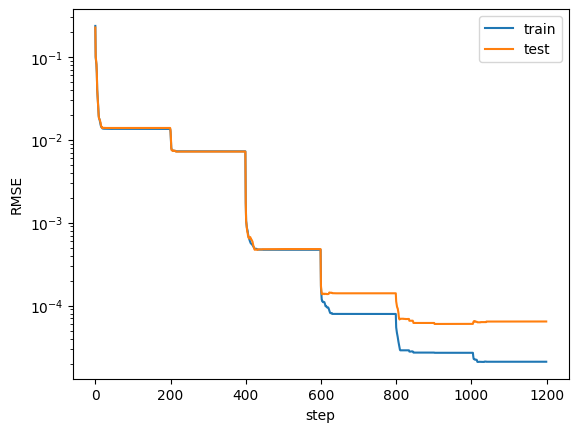

In [7]:
plt.plot(train_losses)
plt.plot(test_losses)
plt.legend(['train', 'test'])
plt.ylabel('RMSE')
plt.xlabel('step')
plt.yscale('log')

Neural scaling laws (For some reason, this got worse than pykan 0.0. We're still investigating the reason, probably due to the updates of curve2coef)

Text(0, 0.5, 'RMSE')

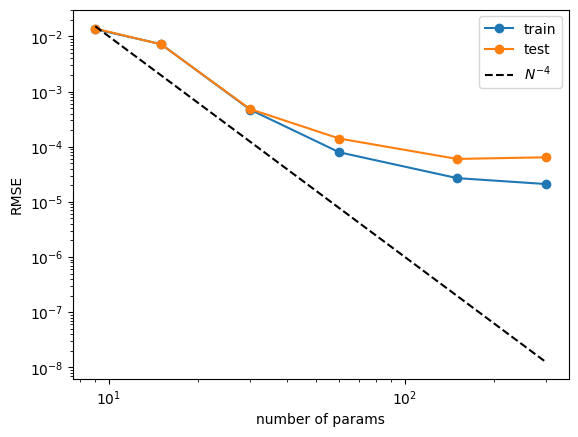

In [8]:
n_params = 3 * grids
train_vs_G = train_losses[(steps-1)::steps]
test_vs_G = test_losses[(steps-1)::steps]
plt.plot(n_params, train_vs_G, marker="o")
plt.plot(n_params, test_vs_G, marker="o")
plt.plot(n_params, 100*n_params**(-4.), ls="--", color="black")
plt.xscale('log')
plt.yscale('log')
plt.legend(['train', 'test', r'$N^{-4}$'])
plt.xlabel('number of params')
plt.ylabel('RMSE')